# Sentiment Analysis with LSTM — Giai đoạn 2: Xây dựng Baseline Model

**Yêu cầu:** đã mount Google Drive và lưu `vocab.pkl`/`imdb_processed.pt` vào `MyDrive/imdb_sentiment_artifacts/` ở Giai đoạn 1. Chỉ cần mount lại Drive, không cần chạy lại pipeline data.

**Nội dung notebook:**
1. Mount Drive + load artifact từ Giai đoạn 1 (vocab, tensors) & tạo lại DataLoader
2. Định nghĩa kiến trúc model: `Embedding + LSTM + Dense(Linear)`
3. Training loop (train/validation) + theo dõi loss/accuracy từng epoch
4. Đánh giá trên tập test: Accuracy, Precision, Recall, F1, Confusion Matrix
5. Vẽ learning curves
6. Lưu model checkpoint (dùng để so sánh với GRU/BiLSTM/GloVe ở Giai đoạn 4)


## 1. Mount Drive, load artifact & tạo lại DataLoader

In [2]:
from google.colab import drive
drive.mount('/content/drive')
ARTIFACT_DIR = "/content/drive/MyDrive/imdb_sentiment_artifacts"

import torch
import pickle
from torch.utils.data import TensorDataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

with open(f"{ARTIFACT_DIR}/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

data = torch.load(f"{ARTIFACT_DIR}/imdb_processed.pt")
X_train_full, y_train_full = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
MAX_LEN = data["max_len"]

VOCAB_SIZE = len(vocab)
print("Vocab size:", VOCAB_SIZE, "| Max len:", MAX_LEN)

full_dataset = TensorDataset(X_train_full, y_train_full)
val_size = int(0.1 * len(full_dataset))
train_size = len(full_dataset) - val_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Mounted at /content/drive
Using device: cuda
Vocab size: 20000 | Max len: 250
Train: 22500 | Val: 2500 | Test: 25000


## 2. Định nghĩa kiến trúc Baseline: Embedding + LSTM + Dense

- `nn.Embedding`: vocab_size → embedding_dim (mặc định 128)
- `nn.LSTM`: 1 layer, hidden_dim mặc định 128, lấy hidden state cuối cùng
- `nn.Linear`: hidden_dim → 1 (output logit, dùng `BCEWithLogitsLoss` nên không cần Sigmoid thủ công)

In [3]:
import torch.nn as nn

class LSTMSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):
        # Bỏ qua phần padding khi tính hidden state, tránh hidden state cuối bị nhiễu
        lengths = (x != self.pad_idx).sum(dim=1).cpu()
        embedded = self.embedding(x)                  # (batch, seq_len, embedding_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)             # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)                     # (batch, hidden_dim)
        out = self.dropout(hidden)
        logits = self.fc(out).squeeze(1)               # (batch,)
        return logits

model = LSTMSentimentModel(vocab_size=VOCAB_SIZE).to(device)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nSố tham số huấn luyện được: {num_params:,}")

LSTMSentimentModel(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Số tham số huấn luyện được: 2,692,225


## 3. Training loop (train/validation)

In [4]:
import torch.optim as optim
import time

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def compute_accuracy(logits, labels):
    preds = (torch.sigmoid(logits) >= 0.5).float()
    return (preds == labels).float().mean().item()

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item()
            total_acc += compute_accuracy(logits, yb)
            n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


In [5]:
NUM_EPOCHS = 15
PATIENCE = 3  # dừng sớm nếu val loss không cải thiện sau 3 epoch liên tiếp

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{ARTIFACT_DIR}/baseline_lstm_best.pt")

    print(f"Epoch {epoch}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    # Early stopping dựa trên val loss
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping tại epoch {epoch} (val loss không cải thiện sau {PATIENCE} epoch liên tiếp).")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/15 (8.2s) | Train loss: 0.6284, acc: 0.6402 | Val loss: 0.5707, acc: 0.7203
Epoch 2/15 (5.7s) | Train loss: 0.5032, acc: 0.7661 | Val loss: 0.4790, acc: 0.7902
Epoch 3/15 (7.1s) | Train loss: 0.4193, acc: 0.8191 | Val loss: 0.4573, acc: 0.8000
Epoch 4/15 (5.7s) | Train loss: 0.3372, acc: 0.8639 | Val loss: 0.4090, acc: 0.8289
Epoch 5/15 (5.4s) | Train loss: 0.2723, acc: 0.8924 | Val loss: 0.4022, acc: 0.8234
Epoch 6/15 (7.5s) | Train loss: 0.2119, acc: 0.9214 | Val loss: 0.4085, acc: 0.8398
Epoch 7/15 (5.5s) | Train loss: 0.1732, acc: 0.9381 | Val loss: 0.4237, acc: 0.8445
Epoch 8/15 (6.9s) | Train loss: 0.1342, acc: 0.9522 | Val loss: 0.4941, acc: 0.8137

Early stopping tại epoch 8 (val loss không cải thiện sau 3 epoch liên tiếp).

Best validation accuracy: 0.8445


## 4. Đánh giá trên tập test: Accuracy, Precision, Recall, F1, Confusion Matrix

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Load lại best checkpoint theo validation accuracy
model.load_state_dict(torch.load(f"{ARTIFACT_DIR}/baseline_lstm_best.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = (torch.sigmoid(logits) >= 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")
print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=["negative", "positive"]))


Test Accuracy : 0.8439
Precision     : 0.8468
Recall        : 0.8398
F1-score      : 0.8433

Classification report:
              precision    recall  f1-score   support

    negative       0.84      0.85      0.84     12500
    positive       0.85      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



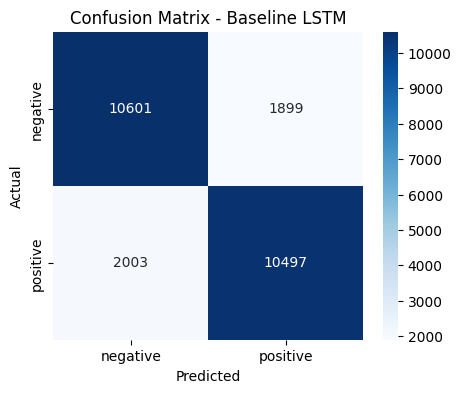

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline LSTM")
plt.show()


## 5. Vẽ learning curves (loss/accuracy theo epoch)

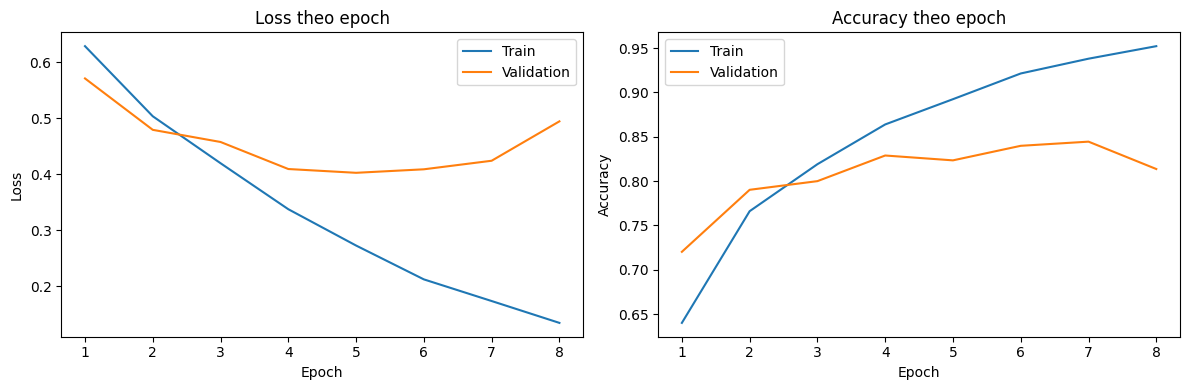

In [8]:
epochs_range = range(1, len(history["train_loss"]) + 1)  # dùng độ dài thật (có thể ít hơn NUM_EPOCHS do early stopping)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Validation")
axes[0].set_title("Loss theo epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Validation")
axes[1].set_title("Accuracy theo epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Lưu kết quả Baseline để so sánh ở Giai đoạn 4/5

In [9]:
import json

baseline_results = {
    "model_name": "Baseline (Embedding + LSTM + Dense)",
    "num_params": num_params,
    "test_accuracy": acc,
    "test_precision": prec,
    "test_recall": rec,
    "test_f1": f1,
    "history": history,
}

with open(f"{ARTIFACT_DIR}/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Đã lưu baseline_results.json — dùng để so sánh với GRU / BiLSTM / GloVe ở các bước sau.")


Đã lưu baseline_results.json — dùng để so sánh với GRU / BiLSTM / GloVe ở các bước sau.


---
### ✅ Kết thúc Giai đoạn 2

Đã có:
- Model baseline `Embedding + LSTM + Dense` huấn luyện xong, checkpoint tốt nhất lưu tại `baseline_lstm_best.pt`
- Đầy đủ metrics (Accuracy/Precision/Recall/F1), confusion matrix, learning curves
- `baseline_results.json` lưu lại để dùng cho bảng so sánh cuối cùng (Giai đoạn 5)

**Bước tiếp theo (Giai đoạn 3 trong kế hoạch gốc đã gộp vào đây — đánh giá xong).**
**Giai đoạn 4:** copy notebook này, chỉ đổi phần kiến trúc model sang GRU / Bidirectional LSTM / GloVe embeddings, giữ nguyên phần data loading, training loop, và đánh giá.
